# Exercise: Build a Denoising Convolutional Autoencoder

1. Dataset Preparation and Preprocessing:

    • Load the Devnagari dataset using PIL.

    • Normalize the images to the range [0, 1].

    • Reshape the images to include a channel dimension for Keras Compatibility.

    • Split the dataset into training and validation sets.

    • Add noise to the images for denoising purposes (Gaussian noise or salt-and-pepper noise).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Necessary Imports
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam

Path to the dataset:

In [10]:
#Unzip Dataset
zip_path = "/content/drive/MyDrive/AI-Sem6/Datasets/Copy of devnagari digit.zip"
extract_path = "/content/devnagari_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("Top-level contents:", os.listdir(extract_path))

Dataset extracted successfully.
Top-level contents: ['DevanagariHandwrittenDigitDataset']


In [11]:
#Train and Test paths
base_path = "/content/devnagari_dataset/DevanagariHandwrittenDigitDataset"

train_path = os.path.join(base_path, "Train")
test_path = os.path.join(base_path, "Test")

print("Train path:", train_path)
print("Test path:", test_path)

print("Train folders:", os.listdir(train_path)[:10])
print("Test folders:", os.listdir(test_path)[:10])

Train path: /content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train
Test path: /content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Test
Train folders: ['digit_4', 'digit_1', 'digit_6', 'digit_7', 'digit_3', 'digit_5', 'digit_9', 'digit_2', 'digit_0', 'digit_8']
Test folders: ['digit_4', 'digit_1', 'digit_6', 'digit_7', 'digit_3', 'digit_5', 'digit_9', 'digit_2', 'digit_0', 'digit_8']


**Load the dataset**

In [12]:
def load_images_from_folders(dataset_path, img_size=(28, 28)):
    images = []

    # Go through each class folder
    for class_name in sorted(os.listdir(dataset_path)):
        class_folder = os.path.join(dataset_path, class_name)

        if not os.path.isdir(class_folder):
            continue

        # Go through each file inside class folder
        for file_name in os.listdir(class_folder):
            file_path = os.path.join(class_folder, file_name)

            # Skip if it is not a file
            if not os.path.isfile(file_path):
                continue

            try:
                # Open image as grayscale
                img = Image.open(file_path).convert("L")

                # Resize image to 28x28
                img = img.resize(img_size)

                # Convert to numpy array
                img = np.array(img, dtype="float32")

                # Store image
                images.append(img)

            except Exception as e:
                print("Error reading file:", file_path)
                print(e)

    # Convert list to numpy array
    images = np.array(images)

    return images

**Load train and test data**

In [13]:
x_train = load_images_from_folders(train_path)
x_test = load_images_from_folders(test_path)

print("Training images shape before preprocessing:", x_train.shape)
print("Test images shape before preprocessing:", x_test.shape)

Training images shape before preprocessing: (17000, 28, 28)
Test images shape before preprocessing: (3000, 28, 28)


**Normalize and reshape**

In [14]:
# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to (samples, 28, 28, 1)
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

print("Training shape after preprocessing:", x_train.shape)
print("Test shape after preprocessing:", x_test.shape)
print("Min pixel value:", x_train.min())
print("Max pixel value:", x_train.max())

Training shape after preprocessing: (17000, 28, 28, 1)
Test shape after preprocessing: (3000, 28, 28, 1)
Min pixel value: 0.0
Max pixel value: 1.0


**Add Gaussian noise**

In [15]:
def add_gaussian_noise(data, noise_factor=0.5):
    """
    Add Gaussian noise and clip values to [0, 1].
    """
    noisy_data = data + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=data.shape)
    noisy_data = np.clip(noisy_data, 0.0, 1.0)
    return noisy_data

noise_factor = 0.5

x_train_noisy = add_gaussian_noise(x_train, noise_factor)
x_test_noisy = add_gaussian_noise(x_test, noise_factor)

print("Noisy training shape:", x_train_noisy.shape)
print("Noisy test shape:", x_test_noisy.shape)

Noisy training shape: (17000, 28, 28, 1)
Noisy test shape: (3000, 28, 28, 1)


**Visualize noisy VS original images**

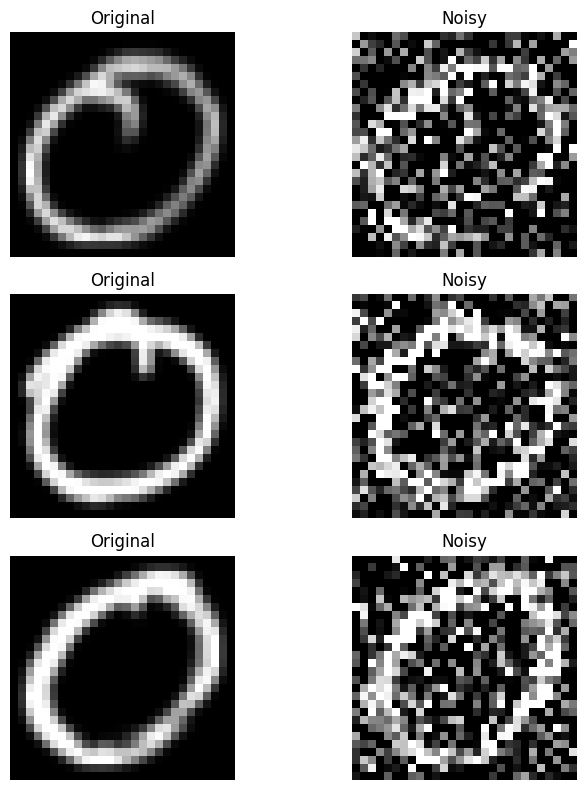

In [16]:
n = 3
plt.figure(figsize=(8, 8))

for i in range(n):
    # Original image
    plt.subplot(n, 2, 2 * i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy image
    plt.subplot(n, 2, 2 * i + 2)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

**2. Build the Denoising Convolutional Autoencoder:**

Build a convolutional autoencoder with at least 4 layers. The model should have an encoder to compress the input and a decoder to reconstruct the original image.

    • Use convolutional layers for the encoder and decoder.

    • Use ReLU activations for hidden layers and sigmoid for the output layer.

In [17]:
def build_encoder(input_shape=(28, 28, 1)):
    """
    Build encoder part of convolutional autoencoder.
    """
    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = MaxPooling2D((2, 2), padding="same")(x)

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    encoded = MaxPooling2D((2, 2), padding="same", name="encoded")(x)

    return input_img, encoded

In [18]:
def build_decoder(encoded_input):
    """
    Build decoder part of convolutional autoencoder.
    """
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoded")(x)

    return decoded

In [19]:
def build_autoencoder():
    """
    Connect encoder and decoder and compile model.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss="binary_crossentropy")

    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

**3. Train the Denoising Autoencoder:**

Train the model with the noisy images as inputs and the original images as targets. Monitor the training
process by plotting the loss curves.

In [20]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 30s 216ms/step - loss: 0.3195 - val_loss: 0.2159
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 29s 216ms/step - loss: 0.2081 - val_loss: 0.2006
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 31s 230ms/step - loss: 0.1987 - val_loss: 0.1946
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - loss: 0.1940 - val_loss: 0.1912
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 39s 221ms/step - loss: 0.1912 - val_loss: 0.1890
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 28s 211ms/step - loss: 0.1892 - val_loss: 0.1874
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 41s 212ms/step - loss: 0.1874 - val_loss: 0.1864
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 28s 210ms/step - loss: 0.1862 - val_loss: 0.1853
Epoch 9/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 42s 215ms/step - loss: 0.1851 - val_loss: 0.1841
Epoch 10/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 28s 210ms/step - loss: 0.1842 - val_loss: 0.1834


**4. Evaluate and Visualize the Results:**

Evaluate the performance of the denoising autoencoder by visualizing a few noisy images, the denoised
images generated by the model, and the original clean images.

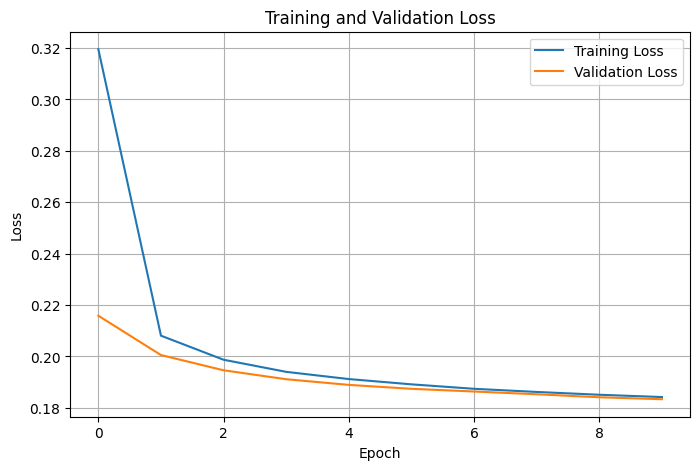

In [21]:
#Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
#Predict denoised images
denoised_images = autoencoder.predict(x_test_noisy)
print("Denoised images shape:", denoised_images.shape)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
Denoised images shape: (3000, 28, 28, 1)


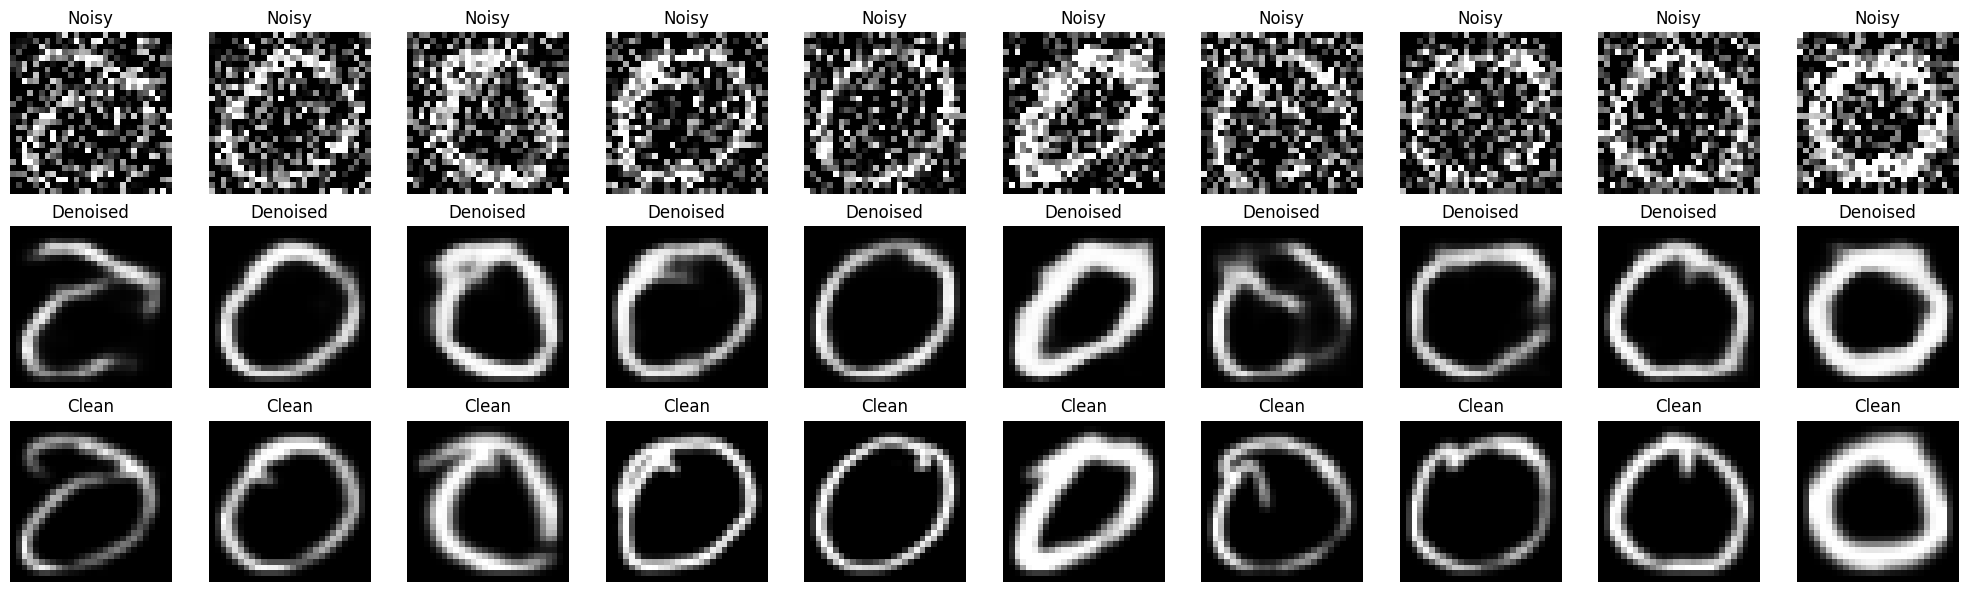

In [23]:
#Visualize noisy, denoised, and clean images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    """
    Display noisy, denoised, and clean images.
    """
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy image
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        # Denoised image
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
        plt.title("Denoised")
        plt.axis("off")

        # Clean image
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap="gray")
        plt.title("Clean")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_images(x_test_noisy, denoised_images, x_test, n=10)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Results for noise factor = 0.3


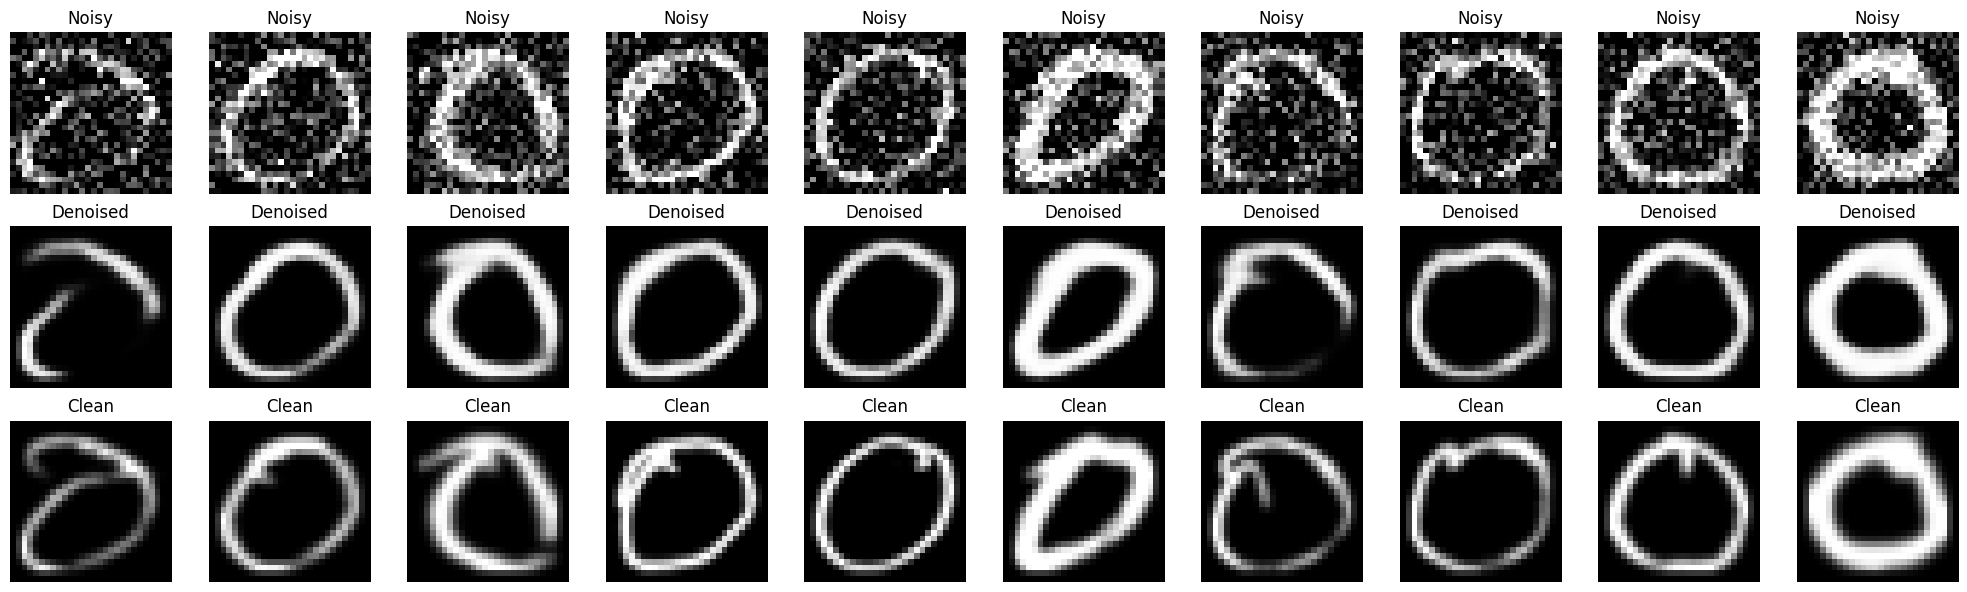

In [25]:
# Introducing Smaller noise
new_noise_factor = 0.3

x_test_noisy_2 = add_gaussian_noise(x_test, new_noise_factor)
denoised_images_2 = autoencoder.predict(x_test_noisy_2)

print("Results for noise factor =", new_noise_factor)
plot_images(x_test_noisy_2, denoised_images_2, x_test, n=10)

The model worked better with the lower noise level. When the noise factor was **0.3**, the images were less noisy, so the autoencoder could make them cleaner more easily. When the noise factor was **0.5**, the images had more noise, so the output was not as clear. This shows that the model gives better results when the noise is lower.